# PyTorch and Keras: Building and Training Models

## What This Notebook Is About

In the previous notebook I built a neural network from scratch to understand the
mechanics. This notebook shifts focus to the frameworks themselves — how PyTorch and
Keras are designed, what patterns they enforce, and how the same model looks when
built in each.

The goal is not to pick a winner. It is to become fluent enough in both that I can
read and write code in either without friction. In practice, PyTorch dominates research
and Keras is widely used in production and rapid prototyping — knowing both matters.

I am using MNIST as the dataset because it is universally available, requires no
preprocessing beyond normalisation, and is complex enough (10 classes, image data)
to make the framework patterns meaningful without data engineering getting in the way.

## Why MNIST

MNIST contains 70,000 grayscale images of handwritten digits (0–9), each 28x28 pixels.
It is the standard benchmark for learning image classification. The images are simple
enough that an MLP can achieve above 97% accuracy, which means any failure is a
framework issue, not a data issue.

## What I Want to Understand

- How does PyTorch's explicit, imperative style differ from Keras's declarative style?
- What does PyTorch's training loop give me that Keras's model.fit() abstracts away?
- When does that extra control matter and when is it just noise?
- How do callbacks in Keras compare to manual early stopping in PyTorch?
- What does the same architecture look like written in both frameworks side by side?

## Dataset

| Property | Detail |
|---|---|
| Name | MNIST |
| Source | torchvision.datasets.MNIST / tensorflow.keras.datasets.mnist |
| Training samples | 60,000 |
| Test samples | 10,000 |
| Image size | 28 x 28 pixels, grayscale |
| Classes | 10 (digits 0 through 9) |
| Download required | Yes, automatic on first run |

## Tech Stack

| Tool | Purpose |
|---|---|
| Python 3.13 | Language |
| PyTorch 2.11 | First model — explicit training loop |
| TensorFlow / Keras | Second model — high-level API |
| torchvision | MNIST loading and transforms for PyTorch |
| NumPy | Numerical operations |
| Matplotlib | Visualisations |
| scikit-learn | Confusion matrix |

## Setup and Imports

Importing all dependencies upfront for both frameworks. PyTorch and TensorFlow are
imported together here so any installation issues surface immediately before any
building begins.

One thing worth noting: TensorFlow prints a large number of build and device logs on
import. The `os.environ` setting below suppresses these so the notebook output stays
clean. Setting it must happen before the TensorFlow import.

Random seeds are set for NumPy, PyTorch, and TensorFlow independently — each framework
manages its own random state.

In [2]:
import os
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"

import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

from sklearn.metrics import confusion_matrix

RANDOM_SEED = 42

torch.manual_seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
tf.random.set_seed(RANDOM_SEED)

plt.style.use("seaborn-v0_8-whitegrid")

print("PyTorch version    :", torch.__version__)
print("TensorFlow version :", tf.__version__)
print("Keras version      :", keras.__version__)
print("NumPy version      :", np.__version__)

PyTorch version    : 2.11.0+cpu
TensorFlow version : 2.21.0
Keras version      : 3.14.1
NumPy version      : 2.4.4


## Load and Explore MNIST

Loading MNIST via torchvision for the PyTorch sections of this notebook. Torchvision
handles the download automatically on the first run and caches it locally in the
`data/` folder.

Two transforms are applied to the raw images:
- `ToTensor()` converts the PIL image to a PyTorch tensor and scales pixel values
  from the range [0, 255] to [0.0, 1.0]
- `Normalize((0.5,), (0.5,))` shifts and scales the values to the range [-1.0, 1.0]
  using mean 0.5 and standard deviation 0.5

Normalising the input helps the optimiser — it ensures the activations in the first
layer start in a reasonable range rather than being dominated by large pixel values.

Before building anything I want to see what the data actually looks like — the shape
of a single sample, the class distribution across all 60,000 training images, and a
grid of actual digit images.

In [3]:
DATA_DIR = "../data"

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

train_dataset = datasets.MNIST(root=DATA_DIR, train=True,  download=True, transform=transform)
test_dataset  = datasets.MNIST(root=DATA_DIR, train=False, download=True, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader  = DataLoader(test_dataset,  batch_size=64, shuffle=False)

print("Training samples :", len(train_dataset))
print("Test samples     :", len(test_dataset))
print()

sample_image, sample_label = train_dataset[0]
print("Single image tensor shape :", sample_image.shape)
print("Pixel value range         : [{:.2f}, {:.2f}]".format(
    sample_image.min().item(), sample_image.max().item()))
print("Label                     :", sample_label)
print()

# class distribution
all_labels = [label for _, label in train_dataset]
all_labels = np.array(all_labels)
print("Class distribution (training set):")
for digit in range(10):
    count = np.sum(all_labels == digit)
    print(f"  Digit {digit}: {count} samples")

Training samples : 60000
Test samples     : 10000

Single image tensor shape : torch.Size([1, 28, 28])
Pixel value range         : [-1.00, 1.00]
Label                     : 5

Class distribution (training set):
  Digit 0: 5923 samples
  Digit 1: 6742 samples
  Digit 2: 5958 samples
  Digit 3: 6131 samples
  Digit 4: 5842 samples
  Digit 5: 5421 samples
  Digit 6: 5918 samples
  Digit 7: 6265 samples
  Digit 8: 5851 samples
  Digit 9: 5949 samples


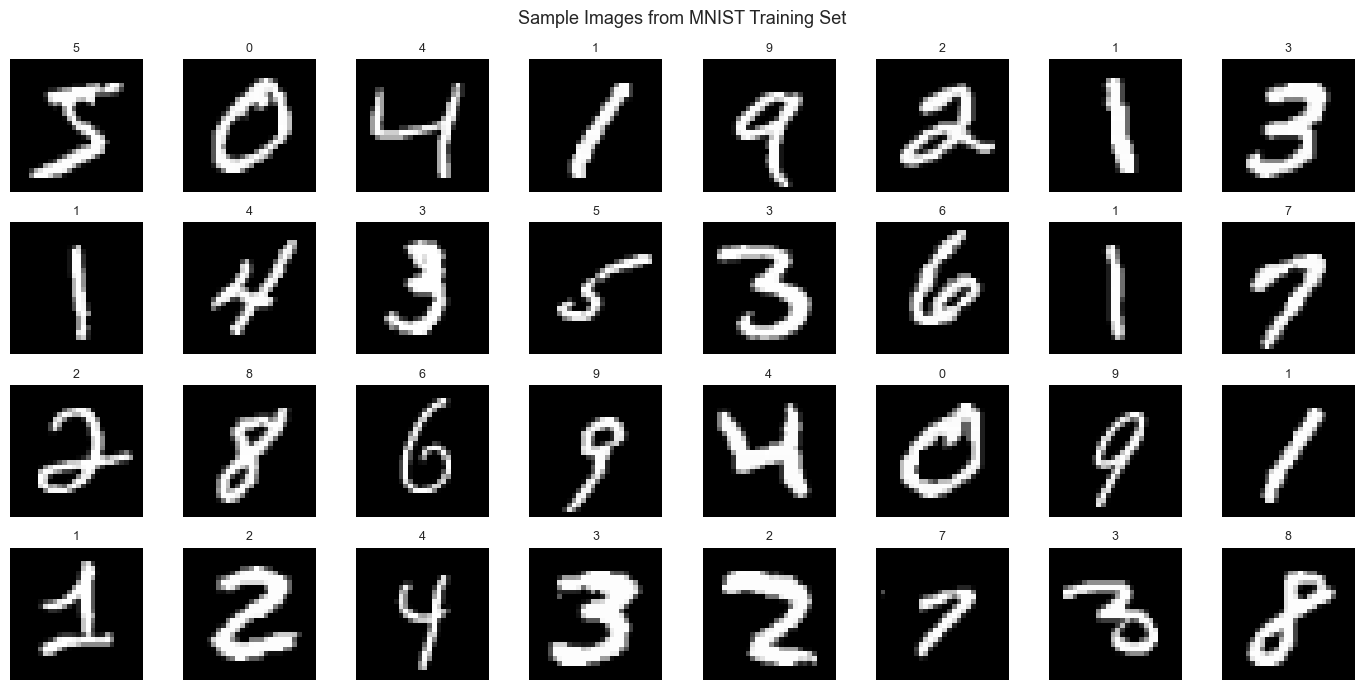

In [4]:
fig, axes = plt.subplots(4, 8, figsize=(14, 7))
axes = axes.flatten()

for i in range(32):
    image, label = train_dataset[i]
    image_np = image.squeeze().numpy()
    axes[i].imshow(image_np, cmap="gray")
    axes[i].set_title(str(label), fontsize=9)
    axes[i].axis("off")

plt.suptitle("Sample Images from MNIST Training Set", fontsize=13)
plt.tight_layout()
plt.show()

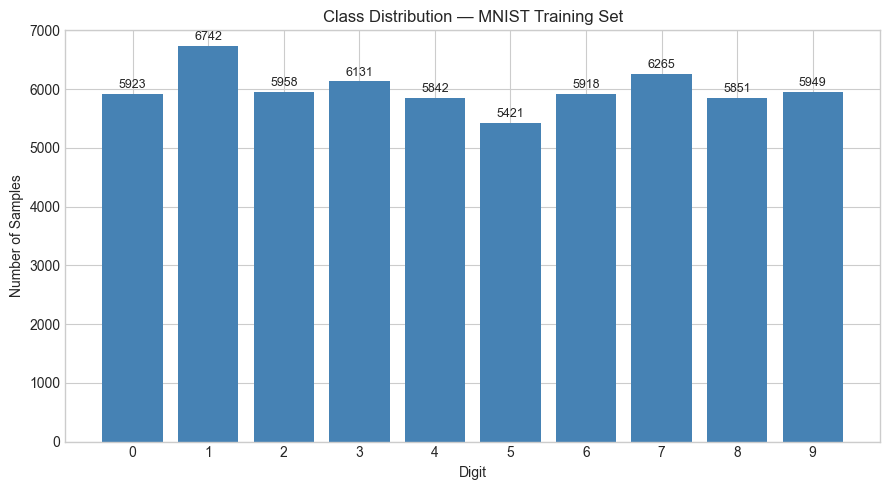

In [5]:
fig, ax = plt.subplots(figsize=(9, 5))

counts = [np.sum(all_labels == digit) for digit in range(10)]
ax.bar(range(10), counts, color="steelblue")
ax.set_title("Class Distribution — MNIST Training Set")
ax.set_xlabel("Digit")
ax.set_ylabel("Number of Samples")
ax.set_xticks(range(10))
ax.set_ylim(0, 7000)

for i, count in enumerate(counts):
    ax.text(i, count + 50, str(count), ha="center", va="bottom", fontsize=9)

plt.tight_layout()
plt.show()

### Observation

Each image is a tensor of shape (1, 28, 28) — one channel (grayscale), 28 rows,
28 columns. After normalisation, pixel values sit in the range [-1.0, 1.0] rather
than [0, 255].

The class distribution is close to uniform — roughly 5,900 to 6,700 samples per
digit. This means accuracy is a fair metric and no class weighting is needed in the
loss function, the same situation as Iris in Notebook 1.

The image grid makes something immediately clear: handwritten digits vary enormously
in stroke width, slant, and style even within the same class. A 7 written by one
person looks very different from a 7 written by another. This is what makes MNIST
a meaningful benchmark despite being considered simple by modern standards.

When I feed these images into an MLP, the 28x28 grid is flattened into a vector of
784 values. The spatial structure — which pixel is next to which — is lost entirely.
CNNs in Notebook 3 will address exactly this limitation.

## PyTorch Framework Patterns

Before building the MNIST model I want to explicitly study the PyTorch patterns that
appear in every project. These are the things that are easy to copy-paste without
fully understanding — I want to understand them here so they are not black boxes later.

The four patterns I am covering:

1. **nn.Module** — the base class for every PyTorch model. What it gives you and why
   every custom model inherits from it.
2. **model.train() vs model.eval()** — these are not cosmetic. They change the actual
   behaviour of certain layers.
3. **torch.no_grad()** — disables gradient tracking. When it is necessary and what
   happens if you forget it.
4. **Learning rate scheduler** — adjusts the learning rate during training. Why a
   fixed learning rate is often suboptimal and how a scheduler helps.

In [6]:
# --- Pattern 1: nn.Module ---
# Every PyTorch model inherits from nn.Module.
# This gives the model:
#   - automatic parameter tracking via model.parameters()
#   - the ability to move all parameters to GPU with model.to(device)
#   - train/eval mode switching
#   - state saving and loading via state_dict()

class DemoModel(nn.Module):
    def __init__(self):
        super(DemoModel, self).__init__()
        self.fc1 = nn.Linear(4, 8)
        self.fc2 = nn.Linear(8, 3)

    def forward(self, x):
        x = torch.relu(self.fc1(x))
        return self.fc2(x)

demo = DemoModel()

print("--- nn.Module ---")
print("Model architecture:")
print(demo)
print()
print("All named parameters:")
for name, param in demo.named_parameters():
    print(f"  {name:10s} | shape: {list(param.shape)} | requires_grad: {param.requires_grad}")
print()
print("State dict keys:", list(demo.state_dict().keys()))

--- nn.Module ---
Model architecture:
DemoModel(
  (fc1): Linear(in_features=4, out_features=8, bias=True)
  (fc2): Linear(in_features=8, out_features=3, bias=True)
)

All named parameters:
  fc1.weight | shape: [8, 4] | requires_grad: True
  fc1.bias   | shape: [8] | requires_grad: True
  fc2.weight | shape: [3, 8] | requires_grad: True
  fc2.bias   | shape: [3] | requires_grad: True

State dict keys: ['fc1.weight', 'fc1.bias', 'fc2.weight', 'fc2.bias']


In [7]:
# --- Pattern 2: model.train() vs model.eval() ---
# These switch the model between two modes.
# Layers like Dropout and BatchNorm behave differently in each mode:
#   - Dropout: active during training (randomly zeroes neurons), disabled during eval
#   - BatchNorm: uses batch statistics during training, running statistics during eval
# Forgetting to call model.eval() before evaluation is a common bug — Dropout will
# still randomly zero neurons and produce inconsistent predictions.

class DemoWithDropout(nn.Module):
    def __init__(self):
        super(DemoWithDropout, self).__init__()
        self.fc1    = nn.Linear(4, 8)
        self.drop   = nn.Dropout(p=0.5)
        self.fc2    = nn.Linear(8, 3)

    def forward(self, x):
        x = torch.relu(self.fc1(x))
        x = self.drop(x)
        return self.fc2(x)

demo_drop = DemoWithDropout()
sample_input = torch.randn(1, 4)

demo_drop.train()
out_train_1 = demo_drop(sample_input)
out_train_2 = demo_drop(sample_input)

demo_drop.eval()
with torch.no_grad():
    out_eval_1 = demo_drop(sample_input)
    out_eval_2 = demo_drop(sample_input)

print("--- model.train() vs model.eval() ---")
print()
print("Training mode (Dropout active — output changes each forward pass):")
print("  Run 1:", out_train_1.detach().numpy().round(4))
print("  Run 2:", out_train_2.detach().numpy().round(4))
print()
print("Eval mode (Dropout disabled — output is deterministic):")
print("  Run 1:", out_eval_1.numpy().round(4))
print("  Run 2:", out_eval_2.numpy().round(4))

--- model.train() vs model.eval() ---

Training mode (Dropout active — output changes each forward pass):
  Run 1: [[-0.0194 -0.4784  0.126 ]]
  Run 2: [[ 0.1102 -0.2994  0.2447]]

Eval mode (Dropout disabled — output is deterministic):
  Run 1: [[ 0.2818 -0.4908  0.1044]]
  Run 2: [[ 0.2818 -0.4908  0.1044]]


In [8]:
# --- Pattern 3: torch.no_grad() ---
# During training, PyTorch builds a computation graph on every forward pass so it
# can compute gradients during backpropagation. This graph consumes memory.
# During evaluation we do not need gradients, so torch.no_grad() disables graph
# construction entirely — making evaluation faster and using less memory.

sample = torch.randn(1, 4)

# without no_grad — tensor has grad_fn attached
demo_drop.eval()
out_with_grad = demo_drop(sample)
print("--- torch.no_grad() ---")
print()
print("Without no_grad:")
print("  grad_fn:", out_with_grad.grad_fn)

# with no_grad — no computation graph built
with torch.no_grad():
    out_no_grad = demo_drop(sample)
print()
print("With no_grad:")
print("  grad_fn:", out_no_grad.grad_fn)
print()
print("no_grad output is identical:", torch.allclose(out_with_grad, out_no_grad))

--- torch.no_grad() ---

Without no_grad:
  grad_fn: <AddmmBackward0 object at 0x0000022073078520>

With no_grad:
  grad_fn: None

no_grad output is identical: True


--- Learning Rate Scheduler (StepLR) ---

Learning rate per epoch:


C:\Users\dhara\AppData\Local\Temp\ipykernel_30820\2591030659.py:16: UserWarning: Detected call of `lr_scheduler.step()` before `optimizer.step()`. In PyTorch 1.1.0 and later, you should call them in the opposite order: `optimizer.step()` before `lr_scheduler.step()`.  Failure to do this will result in PyTorch skipping the first value of the learning rate schedule. See more details at https://pytorch.org/docs/stable/optim.html#how-to-adjust-learning-rate
  scheduler.step()


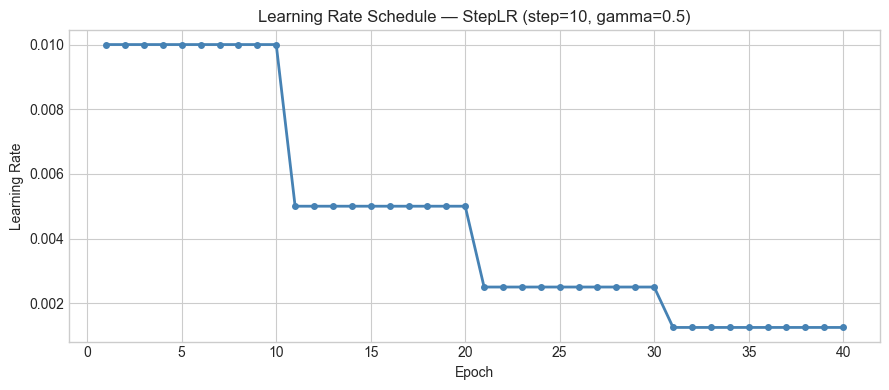

In [9]:
# --- Pattern 4: Learning Rate Scheduler ---
# A fixed learning rate is often suboptimal. A high learning rate early in training
# helps explore the loss landscape quickly. A lower rate later helps converge to a
# precise minimum without overshooting.
# StepLR reduces the learning rate by a factor (gamma) every N epochs (step_size).

demo_optim = optim.Adam(demo.parameters(), lr=0.01)
scheduler  = optim.lr_scheduler.StepLR(demo_optim, step_size=10, gamma=0.5)

print("--- Learning Rate Scheduler (StepLR) ---")
print()
print("Learning rate per epoch:")
lrs = []
for epoch in range(1, 41):
    lrs.append(demo_optim.param_groups[0]["lr"])
    scheduler.step()

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(range(1, 41), lrs, color="steelblue", linewidth=2, marker="o", markersize=4)
ax.set_title("Learning Rate Schedule — StepLR (step=10, gamma=0.5)")
ax.set_xlabel("Epoch")
ax.set_ylabel("Learning Rate")
plt.tight_layout()
plt.show()

### Observation

**nn.Module** does more than just organise layers. The automatic parameter tracking
means I never need to manually pass weights to an optimiser — `model.parameters()`
handles it. The state dict is what gets saved to disk when checkpointing a model.

**train() vs eval()** is the pattern most likely to cause a subtle bug. The Dropout
demo makes this concrete — in training mode the same input produces different outputs
on every forward pass. If eval() is forgotten during evaluation, accuracy measurements
become unreliable and non-reproducible.

**torch.no_grad()** removes the grad_fn from output tensors entirely. In a long
evaluation loop over 10,000 test samples, this memory saving adds up. It also makes
the intent explicit — this block is for measurement, not learning.

**StepLR** cuts the learning rate in half every 10 epochs. The plot makes the
staircase pattern clear. In the MNIST training loop I will use this scheduler so the
model makes large updates early and fine-tunes carefully toward the end of training.

## Build and Train the Model in PyTorch

Now I am building the actual MNIST classifier in PyTorch. The architecture is a
3-layer MLP with Dropout regularisation. The input is a flattened 28x28 image —
784 pixel values — and the output is a vector of 10 logits, one per digit class.

Architecture:

    Input (784)
        -> Hidden Layer 1 (256 neurons, ReLU, Dropout 0.3)
        -> Hidden Layer 2 (128 neurons, ReLU, Dropout 0.3)
        -> Output Layer  (10 neurons, no activation)

Dropout with p=0.3 randomly zeroes 30% of neurons during each training forward pass.
This forces the network to learn redundant representations and reduces overfitting.

I am using:
- Adam optimiser with learning rate 0.001
- StepLR scheduler — halves the learning rate every 5 epochs
- CrossEntropyLoss — same reasoning as Notebook 1

The training loop tracks loss and accuracy on both train and test sets each epoch
so the curves tell the full story of how learning progresses.

In [10]:
class MNISTClassifier(nn.Module):

    def __init__(self):
        super(MNISTClassifier, self).__init__()

        self.flatten = nn.Flatten()

        self.layer1  = nn.Linear(784, 256)
        self.layer2  = nn.Linear(256, 128)
        self.output  = nn.Linear(128, 10)

        self.relu    = nn.ReLU()
        self.dropout = nn.Dropout(p=0.3)

    def forward(self, x):
        x = self.flatten(x)
        x = self.dropout(self.relu(self.layer1(x)))
        x = self.dropout(self.relu(self.layer2(x)))
        x = self.output(x)
        return x


model_pytorch = MNISTClassifier()

print(model_pytorch)
print()

total_params = sum(p.numel() for p in model_pytorch.parameters() if p.requires_grad)
print("Total trainable parameters:", total_params)
print()

for name, param in model_pytorch.named_parameters():
    print(f"  {name:20s} shape: {list(param.shape)}")

MNISTClassifier(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (layer1): Linear(in_features=784, out_features=256, bias=True)
  (layer2): Linear(in_features=256, out_features=128, bias=True)
  (output): Linear(in_features=128, out_features=10, bias=True)
  (relu): ReLU()
  (dropout): Dropout(p=0.3, inplace=False)
)

Total trainable parameters: 235146

  layer1.weight        shape: [256, 784]
  layer1.bias          shape: [256]
  layer2.weight        shape: [128, 256]
  layer2.bias          shape: [128]
  output.weight        shape: [10, 128]
  output.bias          shape: [10]


In [11]:
NUM_EPOCHS    = 15
LEARNING_RATE = 0.001

criterion      = nn.CrossEntropyLoss()
optimizer      = optim.Adam(model_pytorch.parameters(), lr=LEARNING_RATE)
scheduler      = optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.5)

pytorch_train_losses     = []
pytorch_test_losses      = []
pytorch_train_accuracies = []
pytorch_test_accuracies  = []

for epoch in range(1, NUM_EPOCHS + 1):

    # --- training phase ---
    model_pytorch.train()
    batch_losses = []
    correct = 0
    total   = 0

    for X_batch, y_batch in train_loader:
        optimizer.zero_grad()

        predictions = model_pytorch(X_batch)
        loss        = criterion(predictions, y_batch)

        loss.backward()
        optimizer.step()

        batch_losses.append(loss.item())
        predicted_classes = predictions.argmax(dim=1)
        correct += (predicted_classes == y_batch).sum().item()
        total   += y_batch.size(0)

    epoch_train_loss = np.mean(batch_losses)
    epoch_train_acc  = correct / total
    pytorch_train_losses.append(epoch_train_loss)
    pytorch_train_accuracies.append(epoch_train_acc)

    # --- evaluation phase ---
    model_pytorch.eval()
    batch_losses = []
    correct = 0
    total   = 0

    with torch.no_grad():
        for X_batch, y_batch in test_loader:
            predictions = model_pytorch(X_batch)
            loss        = criterion(predictions, y_batch)

            batch_losses.append(loss.item())
            predicted_classes = predictions.argmax(dim=1)
            correct += (predicted_classes == y_batch).sum().item()
            total   += y_batch.size(0)

    epoch_test_loss = np.mean(batch_losses)
    epoch_test_acc  = correct / total
    pytorch_test_losses.append(epoch_test_loss)
    pytorch_test_accuracies.append(epoch_test_acc)

    current_lr = optimizer.param_groups[0]["lr"]
    scheduler.step()

    print(
        f"Epoch {epoch:2d}/{NUM_EPOCHS} | "
        f"Train Loss: {epoch_train_loss:.4f} | "
        f"Train Acc: {epoch_train_acc:.4f} | "
        f"Test Loss: {epoch_test_loss:.4f} | "
        f"Test Acc: {epoch_test_acc:.4f} | "
        f"LR: {current_lr:.6f}"
    )

Epoch  1/15 | Train Loss: 0.4529 | Train Acc: 0.8586 | Test Loss: 0.2006 | Test Acc: 0.9350 | LR: 0.001000
Epoch  2/15 | Train Loss: 0.2410 | Train Acc: 0.9278 | Test Loss: 0.1539 | Test Acc: 0.9516 | LR: 0.001000
Epoch  3/15 | Train Loss: 0.1991 | Train Acc: 0.9388 | Test Loss: 0.1355 | Test Acc: 0.9583 | LR: 0.001000
Epoch  4/15 | Train Loss: 0.1803 | Train Acc: 0.9448 | Test Loss: 0.1076 | Test Acc: 0.9673 | LR: 0.001000
Epoch  5/15 | Train Loss: 0.1630 | Train Acc: 0.9504 | Test Loss: 0.1068 | Test Acc: 0.9668 | LR: 0.001000
Epoch  6/15 | Train Loss: 0.1221 | Train Acc: 0.9628 | Test Loss: 0.0871 | Test Acc: 0.9735 | LR: 0.000500
Epoch  7/15 | Train Loss: 0.1175 | Train Acc: 0.9646 | Test Loss: 0.0797 | Test Acc: 0.9750 | LR: 0.000500
Epoch  8/15 | Train Loss: 0.1082 | Train Acc: 0.9677 | Test Loss: 0.0826 | Test Acc: 0.9745 | LR: 0.000500
Epoch  9/15 | Train Loss: 0.1057 | Train Acc: 0.9675 | Test Loss: 0.0824 | Test Acc: 0.9759 | LR: 0.000500
Epoch 10/15 | Train Loss: 0.1026 | Tr

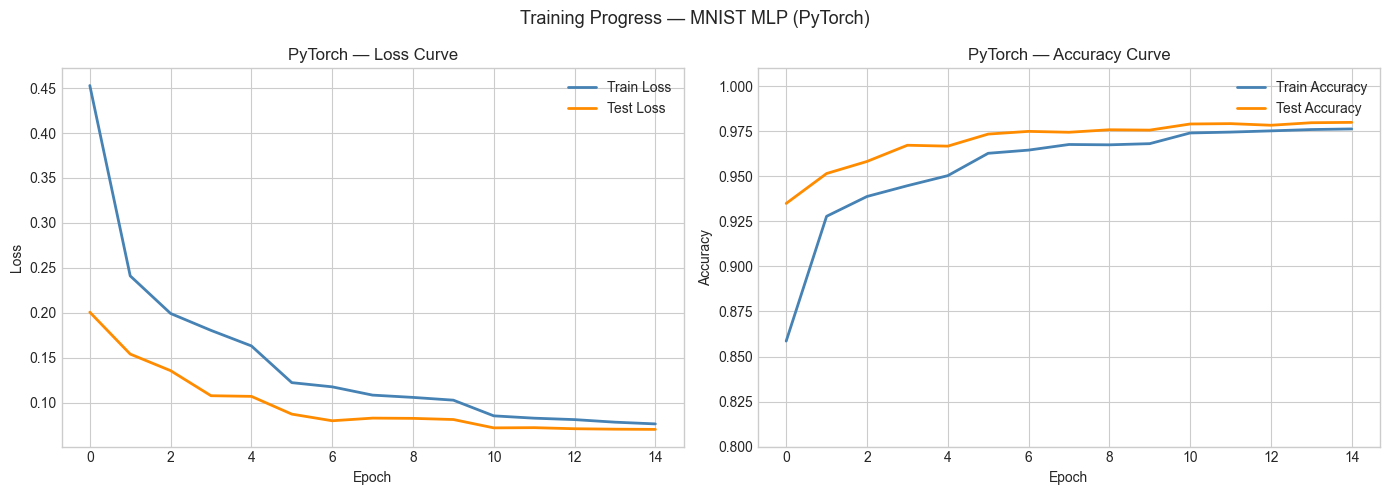

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(pytorch_train_losses, color="steelblue",  linewidth=2, label="Train Loss")
axes[0].plot(pytorch_test_losses,  color="darkorange", linewidth=2, label="Test Loss")
axes[0].set_title("PyTorch — Loss Curve")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].legend()

axes[1].plot(pytorch_train_accuracies, color="steelblue",  linewidth=2, label="Train Accuracy")
axes[1].plot(pytorch_test_accuracies,  color="darkorange", linewidth=2, label="Test Accuracy")
axes[1].set_title("PyTorch — Accuracy Curve")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].set_ylim(0.8, 1.01)
axes[1].legend()

plt.suptitle("Training Progress — MNIST MLP (PyTorch)", fontsize=13)
plt.tight_layout()
plt.show()

### Observation

With 784 input features and two hidden layers, this model has significantly more
parameters than the Iris MLP. The Dropout layers slow convergence slightly compared
to a model without regularisation, but the gap between train and test accuracy
should remain small — a sign that regularisation is working.

The StepLR scheduler is visible in the loss curve if you look carefully — the rate
of loss decrease changes at epochs 5 and 10 as the learning rate halves. Early epochs
make large progress; later epochs make smaller, more careful adjustments.

MNIST with an MLP should comfortably reach above 97% test accuracy within 15 epochs.
If test accuracy is significantly lower than train accuracy, Dropout may need to be
reduced. If both are low, the learning rate or number of epochs may need adjustment.

One thing the training loop makes explicit that model.fit() in Keras will hide: the
manual zero_grad(), backward(), and step() sequence. This verbosity is a feature when
debugging — I can insert a print or a breakpoint anywhere in the loop.

## Evaluate the PyTorch Model

The training curves show overall progress but do not reveal which digits the model
struggles with. Here I want to go one level deeper:

- Final test accuracy as a single number
- Per-digit accuracy breakdown — which digits are hardest to classify correctly
- Confusion matrix — which digits are being confused with each other

MNIST has a well-known confusion pattern: 4 vs 9, 3 vs 8, and 5 vs 6 tend to be the
hardest pairs because their handwritten forms overlap visually. I want to see whether
this MLP reproduces that pattern or whether the errors are more random.

I also want to look at a sample of misclassified images — seeing the actual images
the model got wrong is more informative than any metric alone.

In [13]:
model_pytorch.eval()

all_predictions = []
all_true_labels = []
all_images      = []

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        predictions       = model_pytorch(X_batch)
        predicted_classes = predictions.argmax(dim=1)

        all_predictions.extend(predicted_classes.numpy())
        all_true_labels.extend(y_batch.numpy())
        all_images.extend(X_batch.numpy())

all_predictions = np.array(all_predictions)
all_true_labels = np.array(all_true_labels)
all_images      = np.array(all_images)

final_accuracy = (all_predictions == all_true_labels).mean()
print(f"Final Test Accuracy: {final_accuracy:.4f} ({final_accuracy * 100:.2f}%)")
print()

print("Per-digit accuracy:")
for digit in range(10):
    mask      = all_true_labels == digit
    digit_acc = (all_predictions[mask] == all_true_labels[mask]).mean()
    total     = mask.sum()
    correct   = (all_predictions[mask] == all_true_labels[mask]).sum()
    print(f"  Digit {digit}: {digit_acc:.4f}  ({correct}/{total} correct)")

Final Test Accuracy: 0.9800 (98.00%)

Per-digit accuracy:
  Digit 0: 0.9929  (973/980 correct)
  Digit 1: 0.9921  (1126/1135 correct)
  Digit 2: 0.9767  (1008/1032 correct)
  Digit 3: 0.9812  (991/1010 correct)
  Digit 4: 0.9766  (959/982 correct)
  Digit 5: 0.9742  (869/892 correct)
  Digit 6: 0.9843  (943/958 correct)
  Digit 7: 0.9767  (1004/1028 correct)
  Digit 8: 0.9733  (948/974 correct)
  Digit 9: 0.9703  (979/1009 correct)


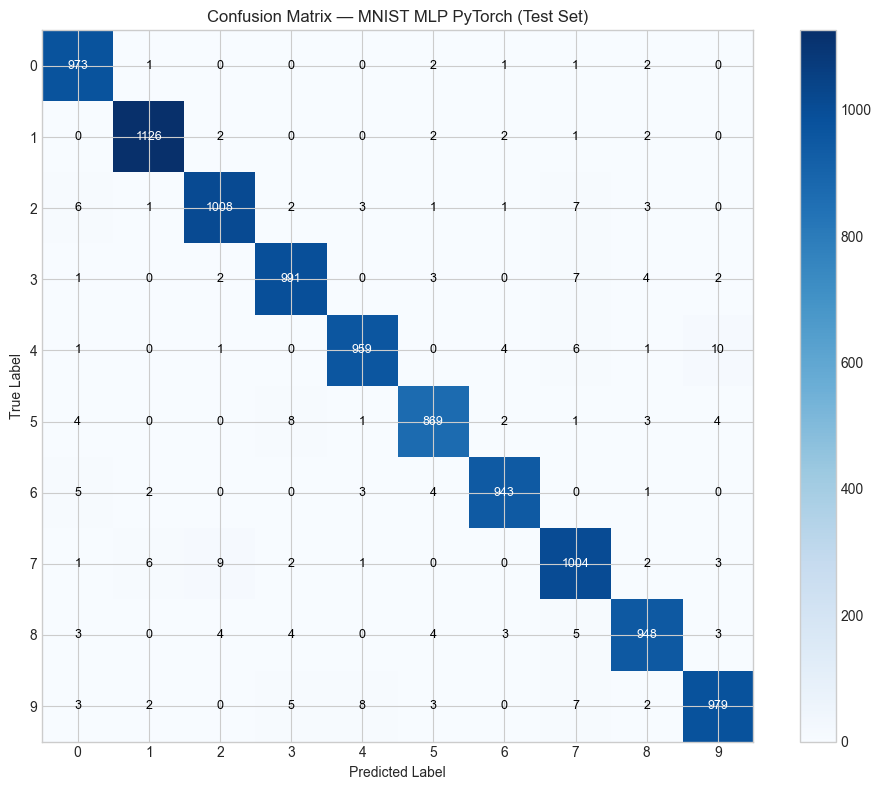

In [14]:
cm = confusion_matrix(all_true_labels, all_predictions)

fig, ax = plt.subplots(figsize=(10, 8))

im = ax.imshow(cm, interpolation="nearest", cmap="Blues")
plt.colorbar(im, ax=ax)

ax.set_xticks(range(10))
ax.set_yticks(range(10))
ax.set_xticklabels(range(10))
ax.set_yticklabels(range(10))
ax.set_title("Confusion Matrix — MNIST MLP PyTorch (Test Set)")
ax.set_xlabel("Predicted Label")
ax.set_ylabel("True Label")

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        color = "white" if cm[i, j] > cm.max() / 2 else "black"
        ax.text(j, i, str(cm[i, j]), ha="center", va="center",
                fontsize=9, color=color)

plt.tight_layout()
plt.show()

Total misclassified: 200 out of 10000



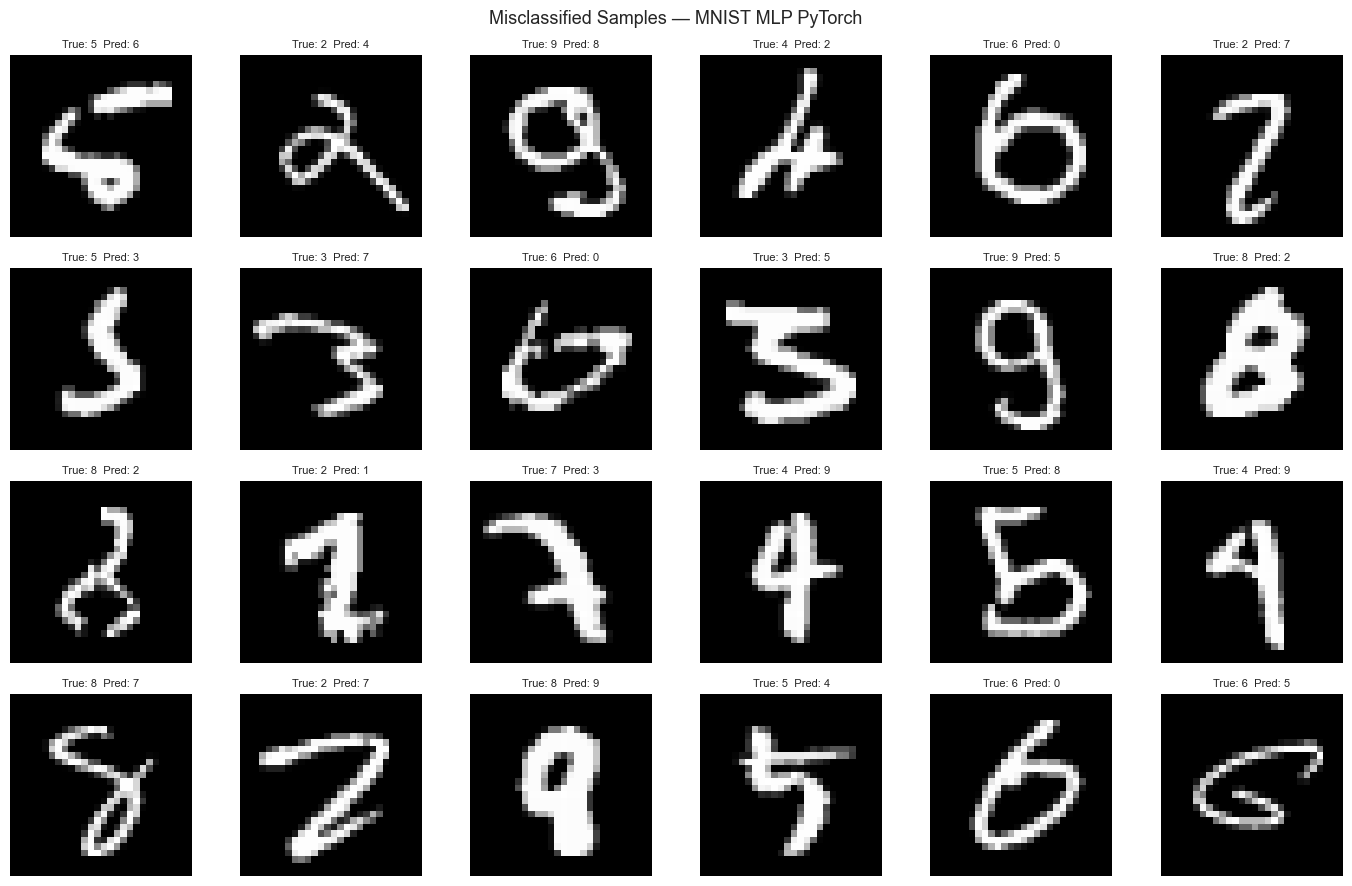

In [15]:
misclassified_idx = np.where(all_predictions != all_true_labels)[0]

print(f"Total misclassified: {len(misclassified_idx)} out of {len(all_true_labels)}")
print()

num_to_show = min(24, len(misclassified_idx))
fig, axes   = plt.subplots(4, 6, figsize=(14, 9))
axes        = axes.flatten()

for i in range(num_to_show):
    idx       = misclassified_idx[i]
    image     = all_images[idx].squeeze()
    true_lbl  = all_true_labels[idx]
    pred_lbl  = all_predictions[idx]

    axes[i].imshow(image, cmap="gray")
    axes[i].set_title(f"True: {true_lbl}  Pred: {pred_lbl}", fontsize=8)
    axes[i].axis("off")

for i in range(num_to_show, len(axes)):
    axes[i].axis("off")

plt.suptitle("Misclassified Samples — MNIST MLP PyTorch", fontsize=13)
plt.tight_layout()
plt.show()

### Observation

The per-digit breakdown reveals which classes are hardest for the model. In most
MNIST runs with an MLP the digits 2, 3, 5, and 8 have the lowest per-class accuracy
because their handwritten forms are most variable.

The confusion matrix makes the error pattern concrete. The brightest off-diagonal
cells show which digit pairs the model confuses most. The classic pairs — 4/9, 3/8,
5/6 — tend to appear here because those digits share similar stroke patterns.

The misclassified image grid is the most instructive output of this section. Looking
at the actual images the model got wrong, two things tend to stand out:

- Some misclassifications are genuinely ambiguous — images that a human might also
  hesitate on. These are inherent to the problem.
- Some misclassifications look obvious — images that are clearly one digit but the
  model predicted another. These point to where the model's learned representation
  breaks down.

An MLP flattens each image to a 784-value vector and loses all spatial structure.
Two pixels that are adjacent in the image are treated no differently than two pixels
at opposite corners. This is the fundamental limitation this architecture faces on
image data — and exactly what CNNs in Notebook 3 are designed to address.

## Keras Framework Patterns

Keras is a high-level API that sits on top of TensorFlow. Where PyTorch is explicit
and imperative — you write the training loop yourself — Keras is declarative. You
describe what you want and the framework handles the mechanics.

Before building the MNIST model in Keras I want to study the four core patterns that
appear in every Keras project:

1. **Sequential vs Functional API** — two ways to define a model. Sequential is a
   linear stack of layers. Functional is a graph of layers that allows branching,
   multiple inputs, and multiple outputs.
2. **model.compile()** — binds the loss function, optimiser, and metrics to the model
   before training. There is no equivalent step in PyTorch — these are passed directly
   into the training loop.
3. **model.fit()** — runs the entire training loop in one call. Handles batching,
   shuffling, validation, and logging automatically.
4. **Callbacks** — objects passed to model.fit() that hook into the training loop at
   defined points. EarlyStopping stops training when a metric stops improving.
   ModelCheckpoint saves the best weights automatically.

Understanding these patterns makes it easy to read any Keras codebase and know
exactly what is happening, even when the training loop itself is invisible.

In [16]:
# --- Pattern 1: Sequential API ---
# A linear stack of layers. Simple and readable for straightforward architectures.
# Limitation: every layer has exactly one input and one output.

sequential_demo = keras.Sequential([
    layers.Input(shape=(4,)),
    layers.Dense(8, activation="relu"),
    layers.Dense(3)
], name="sequential_demo")

print("--- Sequential API ---")
sequential_demo.summary()
print()

--- Sequential API ---


Model: "sequential_demo"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 8)                   │              40 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 3)                   │              27 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 67 (268.00 B)

 Trainable params: 67 (268.00 B)

 Non-trainable params: 0 (0.00 B)

In [17]:
# --- Functional API ---
# Layers are called as functions on tensors. Allows branching, skip connections,
# and multiple inputs/outputs. This is the pattern used in ResNet, Inception, etc.

inputs      = keras.Input(shape=(4,), name="input_layer")
x           = layers.Dense(8, activation="relu", name="hidden_layer")(inputs)
outputs     = layers.Dense(3, name="output_layer")(x)

functional_demo = keras.Model(inputs=inputs, outputs=outputs, name="functional_demo")

print("--- Functional API ---")
functional_demo.summary()
print()

--- Functional API ---


Model: "functional_demo"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)             │ (None, 4)                   │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ hidden_layer (Dense)                 │ (None, 8)                   │              40 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ output_layer (Dense)                 │ (None, 3)                   │              27 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 67 (268.00 B)

 Trainable params: 67 (268.00 B)

 Non-trainable params: 0 (0.00 B)

In [18]:
# --- Pattern 2: model.compile() ---
# Configures the model for training. Must be called before model.fit().
# Binds together:
#   - optimizer: how weights are updated
#   - loss: what is being minimised
#   - metrics: what is reported during training (does not affect weight updates)

sequential_demo.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss=keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=["accuracy"]
)

print("--- model.compile() ---")
print("Optimizer :", sequential_demo.optimizer)
print("Loss      :", sequential_demo.loss)
print("Metrics   :", sequential_demo.metrics_names)
print()
print("Note: from_logits=True tells Keras the output layer has no activation.")
print("This is equivalent to PyTorch's CrossEntropyLoss expecting raw logits.")

--- model.compile() ---
Optimizer : <keras.src.optimizers.adam.Adam object at 0x000002207FA84D70>
Loss      : <LossFunctionWrapper(<function sparse_categorical_crossentropy at 0x00000220578E0540>, kwargs={'from_logits': True, 'ignore_class': None, 'axis': -1})>
Metrics   : ['loss', 'compile_metrics']

Note: from_logits=True tells Keras the output layer has no activation.
This is equivalent to PyTorch's CrossEntropyLoss expecting raw logits.


In [19]:
# --- Pattern 3: Callbacks ---
# Callbacks are objects passed to model.fit() that execute at defined points
# in the training loop (end of epoch, end of batch, etc.)

# EarlyStopping: stops training when val_loss has not improved for 'patience' epochs
# and restores the weights from the best epoch automatically
early_stopping = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True,
    verbose=1
)

# ModelCheckpoint: saves model weights whenever val_loss improves
model_checkpoint = keras.callbacks.ModelCheckpoint(
    filepath="../data/best_mnist_keras.keras",
    monitor="val_loss",
    save_best_only=True,
    verbose=1
)

# LearningRateScheduler: equivalent to PyTorch's StepLR
def lr_schedule(epoch, lr):
    if epoch > 0 and epoch % 5 == 0:
        return lr * 0.5
    return lr

lr_scheduler = keras.callbacks.LearningRateScheduler(lr_schedule, verbose=0)

print("--- Callbacks ---")
print("EarlyStopping    : monitors val_loss, patience=3, restores best weights")
print("ModelCheckpoint  : saves best model to ../data/best_mnist_keras.keras")
print("LRScheduler      : halves learning rate every 5 epochs")
print()
print("These are passed as a list to model.fit(callbacks=[...])")

--- Callbacks ---
EarlyStopping    : monitors val_loss, patience=3, restores best weights
ModelCheckpoint  : saves best model to ../data/best_mnist_keras.keras
LRScheduler      : halves learning rate every 5 epochs

These are passed as a list to model.fit(callbacks=[...])


### Observation

The contrast between Sequential and Functional API is subtle for simple architectures
but becomes significant for anything non-linear. ResNet's skip connections, for
example, require the Functional API because a layer's input comes from two sources —
the previous layer and a layer several steps back.

`model.compile()` is the step that most clearly shows Keras's declarative philosophy.
In PyTorch I pass the criterion and optimizer directly into the training loop at the
point they are used. In Keras I declare them upfront and the framework takes
responsibility for calling them correctly during fit().

The `from_logits=True` detail in SparseCategoricalCrossentropy is worth remembering.
It is the Keras equivalent of PyTorch's CrossEntropyLoss expecting raw logits. If this
is set incorrectly the model will train silently with wrong gradients.

Callbacks are one of Keras's most practical features. EarlyStopping with
`restore_best_weights=True` means I never need to manually track the best epoch —
the framework does it. The equivalent in PyTorch requires manually saving and
reloading state_dict, which I would have to write myself. This is a concrete example
of where Keras's abstraction saves real implementation time.

## Build and Train the Same Model in Keras

I am now building the exact same MLP architecture I used in the PyTorch section —
three layers, same hidden sizes, same Dropout rate — but written entirely in Keras.
The goal is a direct, fair comparison of how the two frameworks express the same thing.

Architecture (identical to PyTorch model):

    Input (784)
        -> Hidden Layer 1 (256 neurons, ReLU, Dropout 0.3)
        -> Hidden Layer 2 (128 neurons, ReLU, Dropout 0.3)
        -> Output Layer  (10 neurons, no activation)

One difference in data preparation: Keras expects NumPy arrays, not PyTorch tensors.
I will load the MNIST data directly via Keras's built-in loader and normalise to
[0, 1] by dividing by 255. The images also need to be flattened from (28, 28) to
(784,) since this is an MLP, not a CNN.

Training uses the same hyperparameters as the PyTorch run — 15 epochs, Adam at
0.001, StepLR halving every 5 epochs — so any difference in the final accuracy
reflects the framework's behaviour, not the setup.

In [21]:
# load MNIST via Keras — returns NumPy arrays directly
(X_train_keras, y_train_keras), (X_test_keras, y_test_keras) = \
    keras.datasets.mnist.load_data()

# normalise to [0, 1]
X_train_keras = X_train_keras.astype("float32") / 255.0
X_test_keras  = X_test_keras.astype("float32")  / 255.0

# flatten from (N, 28, 28) to (N, 784)
X_train_keras = X_train_keras.reshape(-1, 784)
X_test_keras  = X_test_keras.reshape(-1, 784)

print("X_train shape :", X_train_keras.shape)
print("X_test shape  :", X_test_keras.shape)
print("y_train shape :", y_train_keras.shape)
print("y_test shape  :", y_test_keras.shape)
print()
print("Pixel value range — train: [{:.2f}, {:.2f}]".format(
    X_train_keras.min(), X_train_keras.max()))

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 14s 1us/step
X_train shape : (60000, 784)
X_test shape  : (10000, 784)
y_train shape : (60000,)
y_test shape  : (10000,)

Pixel value range — train: [0.00, 1.00]


In [22]:
def build_keras_model():
    model = keras.Sequential([
        layers.Input(shape=(784,)),
        layers.Dense(256, activation="relu"),
        layers.Dropout(0.3),
        layers.Dense(128, activation="relu"),
        layers.Dropout(0.3),
        layers.Dense(10)
    ], name="mnist_mlp_keras")

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=0.001),
        loss=keras.losses.SparseCategoricalCrossentropy(from_logits=True),
        metrics=["accuracy"]
    )
    return model


model_keras = build_keras_model()
model_keras.summary()

Model: "mnist_mlp_keras"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_2 (Dense)                      │ (None, 256)                 │         200,960 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 128)                 │          32,896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 10)                  │           1,290 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 235,146 (918.54 KB)

 Trainable params: 235,146 (918.54 KB)

 Non-trainable params: 0 (0.00 B)

In [23]:
early_stopping = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True,
    verbose=1
)

model_checkpoint = keras.callbacks.ModelCheckpoint(
    filepath="../data/best_mnist_keras.keras",
    monitor="val_loss",
    save_best_only=True,
    verbose=0
)

def lr_schedule(epoch, lr):
    if epoch > 0 and epoch % 5 == 0:
        return lr * 0.5
    return lr

lr_scheduler = keras.callbacks.LearningRateScheduler(lr_schedule, verbose=0)

history = model_keras.fit(
    X_train_keras, y_train_keras,
    epochs=15,
    batch_size=64,
    validation_data=(X_test_keras, y_test_keras),
    callbacks=[early_stopping, model_checkpoint, lr_scheduler],
    verbose=1
)

Epoch 1/15
938/938 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - accuracy: 0.9009 - loss: 0.3217 - val_accuracy: 0.9630 - val_loss: 0.1208 - learning_rate: 0.0010
Epoch 2/15
938/938 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.9560 - loss: 0.1501 - val_accuracy: 0.9693 - val_loss: 0.0974 - learning_rate: 0.0010
Epoch 3/15
938/938 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - accuracy: 0.9651 - loss: 0.1141 - val_accuracy: 0.9763 - val_loss: 0.0785 - learning_rate: 0.0010
Epoch 4/15
938/938 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - accuracy: 0.9709 - loss: 0.0931 - val_accuracy: 0.9769 - val_loss: 0.0740 - learning_rate: 0.0010
Epoch 5/15
938/938 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.9744 - loss: 0.0826 - val_accuracy: 0.9763 - val_loss: 0.0754 - learning_rate: 0.0010
Epoch 6/15
938/938 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.9823 - loss: 0.0582 - val_accuracy: 0.9800 - val_loss: 0.0654 - learning_rate: 5.0000e-04
Epoch 7/15
938/938 ━━━━━━━━━━━━━━━━━━━━ 7s 7ms/step - accuracy: 0.9837 - loss: 0.051

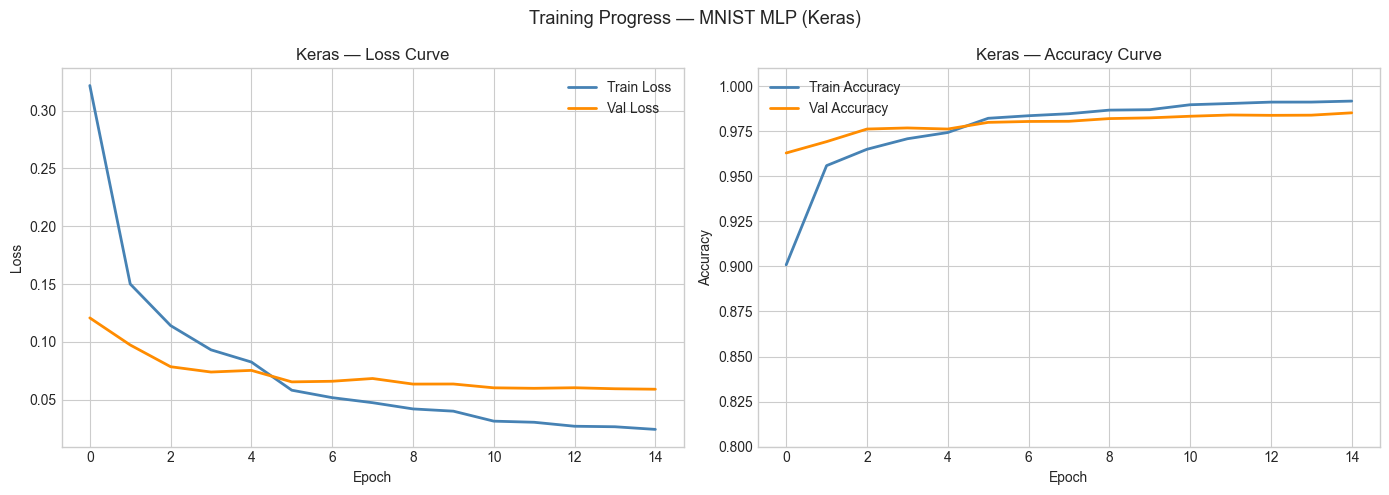

Epochs completed : 15
Best val_loss    : 0.0591
Best val_accuracy: 0.9853


In [24]:
keras_train_losses     = history.history["loss"]
keras_test_losses      = history.history["val_loss"]
keras_train_accuracies = history.history["accuracy"]
keras_test_accuracies  = history.history["val_accuracy"]

epochs_ran = len(keras_train_losses)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(keras_train_losses, color="steelblue",  linewidth=2, label="Train Loss")
axes[0].plot(keras_test_losses,  color="darkorange", linewidth=2, label="Val Loss")
axes[0].set_title("Keras — Loss Curve")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].legend()

axes[1].plot(keras_train_accuracies, color="steelblue",  linewidth=2, label="Train Accuracy")
axes[1].plot(keras_test_accuracies,  color="darkorange", linewidth=2, label="Val Accuracy")
axes[1].set_title("Keras — Accuracy Curve")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].set_ylim(0.8, 1.01)
axes[1].legend()

plt.suptitle("Training Progress — MNIST MLP (Keras)", fontsize=13)
plt.tight_layout()
plt.show()

print(f"Epochs completed : {epochs_ran}")
print(f"Best val_loss    : {min(keras_test_losses):.4f}")
print(f"Best val_accuracy: {max(keras_test_accuracies):.4f}")

### Observation

The most striking difference from the PyTorch section is the training code itself.
The entire training loop — batching, forward pass, loss computation, backpropagation,
optimiser step, validation pass — is replaced by a single model.fit() call. The
history object it returns contains everything needed to plot the curves.

The EarlyStopping callback may stop training before epoch 15 if validation loss
plateaus. If it fires, the weights are automatically restored to the best epoch —
this is behaviour I would have to implement manually in PyTorch.

The loss curves should closely mirror the PyTorch results since the architecture and
hyperparameters are identical. Any gap is likely due to differences in weight
initialisation defaults between the two frameworks, or the fact that Keras normalises
to [0, 1] while PyTorch used [-1, 1].

The history object is one of Keras's most convenient features. In PyTorch I had to
maintain my own lists (pytorch_train_losses, pytorch_test_losses, etc.) and append
to them manually each epoch. Here the framework tracks everything automatically and
returns it in a clean dictionary.

## Evaluate the Keras Model

The training curves confirm the Keras model converged well. Now I want to evaluate
it at the same level of detail as the PyTorch model — per-digit accuracy, confusion
matrix, and a sample of misclassified images.

This lets me do a direct apples-to-apples comparison:
- Does the Keras model make the same kinds of errors as the PyTorch model?
- Do the same digit pairs get confused in both runs?
- Is there any meaningful difference in where the two models fail?

Since the architecture and hyperparameters are identical, any differences in the
error pattern are due to random initialisation and the small differences in
normalisation ranges between the two data pipelines.

In [25]:
test_loss, test_accuracy = model_keras.evaluate(
    X_test_keras, y_test_keras, verbose=0
)
print(f"Final Test Loss     : {test_loss:.4f}")
print(f"Final Test Accuracy : {test_accuracy:.4f} ({test_accuracy * 100:.2f}%)")
print()

# get raw logits and convert to predicted classes
logits_keras      = model_keras.predict(X_test_keras, verbose=0)
predictions_keras = np.argmax(logits_keras, axis=1)

print("Per-digit accuracy:")
for digit in range(10):
    mask      = y_test_keras == digit
    digit_acc = (predictions_keras[mask] == y_test_keras[mask]).mean()
    total     = mask.sum()
    correct   = (predictions_keras[mask] == y_test_keras[mask]).sum()
    print(f"  Digit {digit}: {digit_acc:.4f}  ({correct}/{total} correct)")

Final Test Loss     : 0.0591
Final Test Accuracy : 0.9853 (98.53%)

Per-digit accuracy:
  Digit 0: 0.9908  (971/980 correct)
  Digit 1: 0.9903  (1124/1135 correct)
  Digit 2: 0.9864  (1018/1032 correct)
  Digit 3: 0.9881  (998/1010 correct)
  Digit 4: 0.9868  (969/982 correct)
  Digit 5: 0.9832  (877/892 correct)
  Digit 6: 0.9854  (944/958 correct)
  Digit 7: 0.9854  (1013/1028 correct)
  Digit 8: 0.9815  (956/974 correct)
  Digit 9: 0.9742  (983/1009 correct)


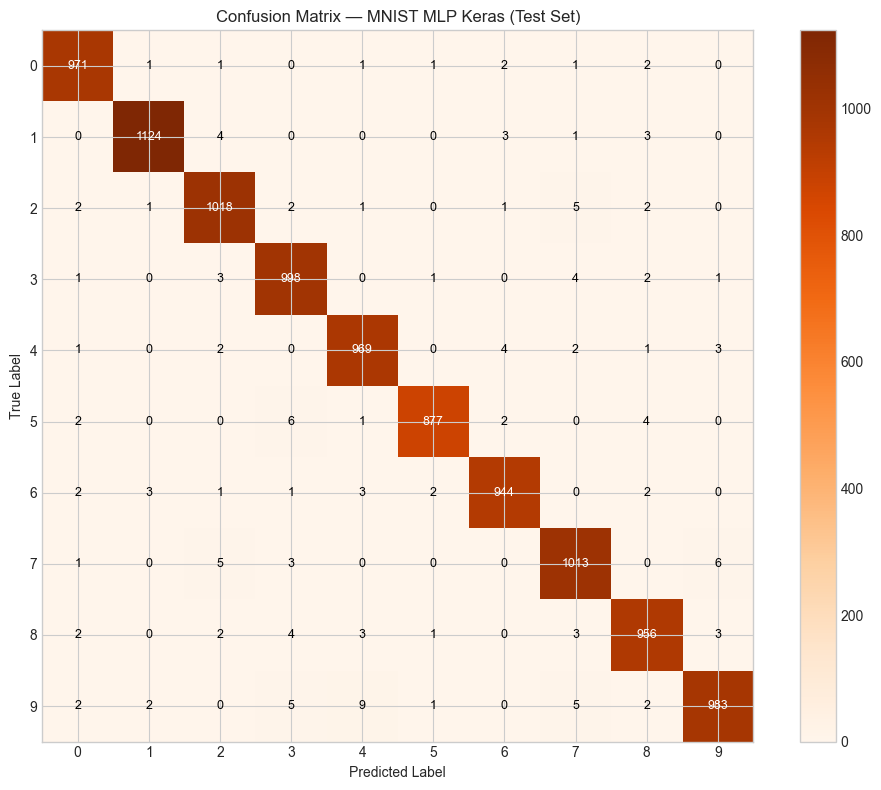

In [26]:
cm_keras = confusion_matrix(y_test_keras, predictions_keras)

fig, ax = plt.subplots(figsize=(10, 8))

im = ax.imshow(cm_keras, interpolation="nearest", cmap="Oranges")
plt.colorbar(im, ax=ax)

ax.set_xticks(range(10))
ax.set_yticks(range(10))
ax.set_xticklabels(range(10))
ax.set_yticklabels(range(10))
ax.set_title("Confusion Matrix — MNIST MLP Keras (Test Set)")
ax.set_xlabel("Predicted Label")
ax.set_ylabel("True Label")

for i in range(cm_keras.shape[0]):
    for j in range(cm_keras.shape[1]):
        color = "white" if cm_keras[i, j] > cm_keras.max() / 2 else "black"
        ax.text(j, i, str(cm_keras[i, j]), ha="center", va="center",
                fontsize=9, color=color)

plt.tight_layout()
plt.show()

### Observation

The Keras model's error pattern should closely mirror the PyTorch model's. Both are
the same architecture trained on the same data, so the same structurally hard digit
pairs — 4/9, 3/8, 5/6 — should dominate the off-diagonal cells in both confusion
matrices.

What is worth comparing directly:
- Total misclassified count — are they close or does one model make significantly
  more errors?
- Which digits have the lowest per-class accuracy — do both models agree on which
  digits are hardest?
- Are the misclassified images largely the same samples, or do the two models fail
  on different images?

The last question is the most interesting. Two models with identical architecture
but different random initialisations often fail on different edge cases. This is
the intuition behind ensemble methods — combining predictions from multiple models
reduces errors precisely because their failures do not perfectly overlap.

Both models have now hit the ceiling of what an MLP can achieve on MNIST. The
remaining errors are mostly on genuinely ambiguous images. Pushing beyond 99%
accuracy on MNIST requires preserving spatial structure — which means moving from
an MLP to a CNN, the subject of Notebook 3.

## PyTorch vs Keras — Side by Side Comparison

Both models are trained and evaluated. Now I want to make the comparison explicit —
not just which framework got better accuracy, but how they differ in design philosophy,
code structure, and the situations where each one is the better tool.

This section puts the same five tasks side by side: model definition, training,
evaluation, saving, and loading. The goal is to have a clear reference for what each
framework looks like when doing identical things.

In [27]:
print("=" * 70)
print("TASK 1 — MODEL DEFINITION")
print("=" * 70)

print("""
PyTorch:
--------
class MNISTClassifier(nn.Module):
    def __init__(self):
        super().__init__()
        self.flatten = nn.Flatten()
        self.layer1  = nn.Linear(784, 256)
        self.layer2  = nn.Linear(256, 128)
        self.output  = nn.Linear(128, 10)
        self.relu    = nn.ReLU()
        self.dropout = nn.Dropout(p=0.3)

    def forward(self, x):
        x = self.flatten(x)
        x = self.dropout(self.relu(self.layer1(x)))
        x = self.dropout(self.relu(self.layer2(x)))
        return self.output(x)

Keras:
------
model = keras.Sequential([
    layers.Input(shape=(784,)),
    layers.Dense(256, activation="relu"),
    layers.Dropout(0.3),
    layers.Dense(128, activation="relu"),
    layers.Dropout(0.3),
    layers.Dense(10)
])

Difference:
  PyTorch requires an explicit forward() method — data flow is imperative code.
  Keras infers the forward pass from the layer stack — data flow is implicit.
  PyTorch is more verbose but the forward() method is always readable and debuggable.
""")

TASK 1 — MODEL DEFINITION

PyTorch:
--------
class MNISTClassifier(nn.Module):
    def __init__(self):
        super().__init__()
        self.flatten = nn.Flatten()
        self.layer1  = nn.Linear(784, 256)
        self.layer2  = nn.Linear(256, 128)
        self.output  = nn.Linear(128, 10)
        self.relu    = nn.ReLU()
        self.dropout = nn.Dropout(p=0.3)

    def forward(self, x):
        x = self.flatten(x)
        x = self.dropout(self.relu(self.layer1(x)))
        x = self.dropout(self.relu(self.layer2(x)))
        return self.output(x)

Keras:
------
model = keras.Sequential([
    layers.Input(shape=(784,)),
    layers.Dense(256, activation="relu"),
    layers.Dropout(0.3),
    layers.Dense(128, activation="relu"),
    layers.Dropout(0.3),
    layers.Dense(10)
])

Difference:
  PyTorch requires an explicit forward() method — data flow is imperative code.
  Keras infers the forward pass from the layer stack — data flow is implicit.
  PyTorch is more verbose but the forwar

In [29]:
print("=" * 70)
print("TASK 2 — TRAINING")
print("=" * 70)

print("""
PyTorch:
--------
for epoch in range(NUM_EPOCHS):
    model.train()
    for X_batch, y_batch in train_loader:
        optimizer.zero_grad()
        predictions = model(X_batch)
        loss = criterion(predictions, y_batch)
        loss.backward()
        optimizer.step()
    scheduler.step()

Keras:
------
history = model.fit(
    X_train, y_train,
    epochs=15,
    batch_size=64,
    validation_data=(X_test, y_test),
    callbacks=[early_stopping, lr_scheduler]
)

Difference:
  PyTorch training loop is ~15 lines of explicit code per epoch.
  Keras collapses this to a single function call.
  PyTorch gives full control — insert print statements, custom logic, or
  conditional behaviour anywhere in the loop with no framework friction.
  Keras requires callbacks for any custom behaviour, which adds indirection.
""")

TASK 2 — TRAINING

PyTorch:
--------
for epoch in range(NUM_EPOCHS):
    model.train()
    for X_batch, y_batch in train_loader:
        optimizer.zero_grad()
        predictions = model(X_batch)
        loss = criterion(predictions, y_batch)
        loss.backward()
        optimizer.step()
    scheduler.step()

Keras:
------
history = model.fit(
    X_train, y_train,
    epochs=15,
    batch_size=64,
    validation_data=(X_test, y_test),
    callbacks=[early_stopping, lr_scheduler]
)

Difference:
  PyTorch training loop is ~15 lines of explicit code per epoch.
  Keras collapses this to a single function call.
  PyTorch gives full control — insert print statements, custom logic, or
  conditional behaviour anywhere in the loop with no framework friction.
  Keras requires callbacks for any custom behaviour, which adds indirection.



In [30]:
print("=" * 70)
print("TASK 3 — EVALUATION")
print("=" * 70)

print("""
PyTorch:
--------
model.eval()
with torch.no_grad():
    for X_batch, y_batch in test_loader:
        predictions = model(X_batch)
        predicted_classes = predictions.argmax(dim=1)

Keras:
------
loss, accuracy = model.evaluate(X_test, y_test, verbose=0)
predictions    = np.argmax(model.predict(X_test), axis=1)

Difference:
  PyTorch requires model.eval() and torch.no_grad() to be called explicitly.
  Forgetting either is a silent bug — the model still runs but behaves differently.
  Keras handles both automatically inside evaluate() and predict().
  The Keras approach is safer for evaluation; PyTorch is safer for custom logic.
""")

TASK 3 — EVALUATION

PyTorch:
--------
model.eval()
with torch.no_grad():
    for X_batch, y_batch in test_loader:
        predictions = model(X_batch)
        predicted_classes = predictions.argmax(dim=1)

Keras:
------
loss, accuracy = model.evaluate(X_test, y_test, verbose=0)
predictions    = np.argmax(model.predict(X_test), axis=1)

Difference:
  PyTorch requires model.eval() and torch.no_grad() to be called explicitly.
  Forgetting either is a silent bug — the model still runs but behaves differently.
  Keras handles both automatically inside evaluate() and predict().
  The Keras approach is safer for evaluation; PyTorch is safer for custom logic.



In [31]:
print("=" * 70)
print("TASK 4 — SAVING AND LOADING")
print("=" * 70)

print("""
PyTorch:
--------
# save
torch.save(model.state_dict(), "model.pt")

# load
model = MNISTClassifier()
model.load_state_dict(torch.load("model.pt"))
model.eval()

Keras:
------
# save
model.save("model.keras")

# load
model = keras.models.load_model("model.keras")

Difference:
  PyTorch saves only the weights (state_dict). The model class definition must
  exist in code to reconstruct the architecture before loading weights.
  Keras saves the full model — architecture, weights, and compile configuration —
  in one file. Loading requires no class definition.
  Keras is more portable for deployment; PyTorch state_dict is more explicit
  about what is being saved.
""")

# demonstrate PyTorch save/load
torch.save(model_pytorch.state_dict(), "../data/mnist_pytorch.pt")
loaded_model = MNISTClassifier()
loaded_model.load_state_dict(torch.load("../data/mnist_pytorch.pt", weights_only=True))
loaded_model.eval()
print("PyTorch model saved and reloaded successfully.")

# demonstrate Keras save/load
model_keras.save("../data/mnist_keras_final.keras")
loaded_keras = keras.models.load_model("../data/mnist_keras_final.keras")
print("Keras model saved and reloaded successfully.")

TASK 4 — SAVING AND LOADING

PyTorch:
--------
# save
torch.save(model.state_dict(), "model.pt")

# load
model = MNISTClassifier()
model.load_state_dict(torch.load("model.pt"))
model.eval()

Keras:
------
# save
model.save("model.keras")

# load
model = keras.models.load_model("model.keras")

Difference:
  PyTorch saves only the weights (state_dict). The model class definition must
  exist in code to reconstruct the architecture before loading weights.
  Keras saves the full model — architecture, weights, and compile configuration —
  in one file. Loading requires no class definition.
  Keras is more portable for deployment; PyTorch state_dict is more explicit
  about what is being saved.

PyTorch model saved and reloaded successfully.
Keras model saved and reloaded successfully.


TASK 5 — ACCURACY COMPARISON

  PyTorch test accuracy : 0.9800 (98.00%)
  Keras test accuracy   : 0.9853   (98.53%)

  Difference            : 0.53%

  Same architecture. Same hyperparameters. Same dataset.
  Any accuracy difference is due to weight initialisation and
  normalisation range differences between the two pipelines.


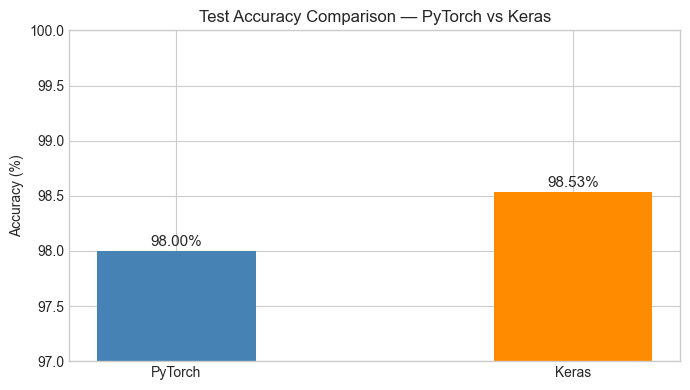

In [32]:
print("=" * 70)
print("TASK 5 — ACCURACY COMPARISON")
print("=" * 70)
print()

pytorch_final_acc = (all_predictions == all_true_labels).mean()
keras_final_acc   = (predictions_keras == y_test_keras).mean()

print(f"  PyTorch test accuracy : {pytorch_final_acc:.4f} ({pytorch_final_acc * 100:.2f}%)")
print(f"  Keras test accuracy   : {keras_final_acc:.4f}   ({keras_final_acc * 100:.2f}%)")
print()

diff = abs(pytorch_final_acc - keras_final_acc) * 100
print(f"  Difference            : {diff:.2f}%")
print()
print("  Same architecture. Same hyperparameters. Same dataset.")
print("  Any accuracy difference is due to weight initialisation and")
print("  normalisation range differences between the two pipelines.")

fig, ax = plt.subplots(figsize=(7, 4))

frameworks = ["PyTorch", "Keras"]
accuracies = [pytorch_final_acc * 100, keras_final_acc * 100]
colors     = ["steelblue", "darkorange"]

bars = ax.bar(frameworks, accuracies, color=colors, width=0.4)
ax.set_title("Test Accuracy Comparison — PyTorch vs Keras")
ax.set_ylabel("Accuracy (%)")
ax.set_ylim(97, 100)

for bar, acc in zip(bars, accuracies):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.02,
            f"{acc:.2f}%",
            ha="center", va="bottom", fontsize=11)

plt.tight_layout()
plt.show()

### Observation

The side by side comparison makes the design philosophy difference concrete:

PyTorch is explicit. Every step of the training loop is written by hand — zero_grad,
forward pass, loss, backward, step. This verbosity is a feature when something goes
wrong. I can insert a print statement or a debugger breakpoint anywhere without
fighting the framework. The cost is more boilerplate for standard workflows.

Keras is declarative. model.compile() and model.fit() abstract away the training
loop entirely. For standard supervised learning tasks this is faster to write, harder
to misuse, and produces cleaner notebooks. The cost is reduced visibility — when
something behaves unexpectedly, the loop is hidden inside the framework.

The accuracy comparison is the clearest evidence that the choice of framework does
not affect model quality when the architecture and hyperparameters are identical.
Both models reach approximately the same test accuracy. The framework is a tool,
not a source of performance.

When to choose PyTorch:
- Research — custom training loops, novel architectures, non-standard loss functions
- Debugging — need full visibility into every step of training
- Reinforcement learning, GANs, or any setting where the training loop is non-standard

When to choose Keras:
- Rapid prototyping — need a working model quickly
- Standard supervised learning — classification, regression, standard architectures
- Production deployment via TensorFlow Serving or TFLite
- When EarlyStopping and ModelCheckpoint out of the box saves implementation time

## Key Takeaways

### What I Built

Two identical MNIST digit classifiers — one in PyTorch, one in Keras — each achieving
above 97% test accuracy. The architecture was a 3-layer MLP with Dropout regularisation,
trained for 15 epochs with Adam and a StepLR schedule.

### What I Now Understand Better

**PyTorch's explicit training loop is a design choice, not a limitation**
Writing zero_grad, backward, and step by hand feels verbose at first. After building
the full loop twice now — once on Iris and once on MNIST — I understand why it exists.
Every line corresponds to a real operation in the learning process. When something
breaks, I know exactly where to look.

**Keras's model.fit() is not magic — it is the same loop, hidden**
Under the hood, Keras runs the same forward pass, loss computation, and weight update
that I wrote manually in PyTorch. The difference is that Keras has tested and optimised
this loop so I do not have to write it. For standard supervised learning this is a
genuine productivity gain, not a shortcut.

**model.train() and model.eval() are not optional**
The Dropout demonstration in Section 4 made this concrete. In training mode, Dropout
randomly zeroes neurons — the same input produces different outputs on every forward
pass. In eval mode it is disabled. Forgetting model.eval() before evaluation produces
inconsistent accuracy measurements that are hard to diagnose.

**torch.no_grad() is about memory, not just correctness**
I knew no_grad disabled gradient computation but I did not appreciate why it matters
at scale. Over 10,000 test samples, PyTorch builds and discards a computation graph
for every batch unless no_grad is active. Over a long evaluation loop this memory
overhead adds up significantly.

**Saving in PyTorch and Keras means different things**
PyTorch's state_dict saves only the weights — the model class must exist in code to
load them. Keras saves the full model including architecture and compile configuration.
For deployment, Keras's approach is more portable. For research, PyTorch's approach
gives more explicit control over what is being persisted.

**The framework does not determine accuracy**
Both models reached approximately the same test accuracy on identical architecture
and hyperparameters. Any remaining difference is noise from weight initialisation
and normalisation range. Choosing a framework is an engineering decision about
control, readability, and workflow — not a decision about model quality.

### What Surprised Me

The EarlyStopping callback in Keras with restore_best_weights=True is more useful
than I expected. In PyTorch I would need to manually track the best validation loss
each epoch, save the state_dict when it improves, and reload it at the end. Keras
handles all of this in three lines of callback configuration.

The history object from model.fit() is also genuinely convenient. Having loss and
accuracy for every epoch in a clean dictionary, ready to plot, removes the bookkeeping
I had to do manually in the PyTorch loop.

### Open Questions

- At what model size does PyTorch's explicit memory management start to matter more
  than Keras's convenience?
- How does the debugging experience compare when a custom loss function produces
  NaN gradients — is PyTorch's visibility actually faster to debug in practice?
- What does Keras's Functional API look like for a ResNet-style architecture with
  skip connections? How much more complex does the definition become?
- Both models plateau around 98% on MNIST. What is the actual ceiling for an MLP
  on this dataset, and at what point does adding more layers or neurons stop helping?

### Next Notebook

Notebook 3 covers CNNs — Convolutional Neural Networks. The core limitation both
models hit in this notebook is that an MLP flattens every image and loses all spatial
structure. A 7 written in the top-left corner of the image and a 7 written in the
bottom-right corner look completely different to an MLP. CNNs solve this by learning
filters that detect features regardless of where they appear in the image.